# JacobianODE — Fully Observed 3D Lorenz

This notebook tests the **vanilla JacobianODE** model (no latent encoder) on the **fully observed** Lorenz system:
- **Input**: Fully observed 3D Lorenz system (all 3 coordinates visible)
- **Model**: MLP that directly predicts Jacobians from state vectors
- **No encoder/decoder** — the Jacobian MLP operates directly on observation space

## Two Validation Tests

1. **Lyapunov Exponent Test** — Predicted Jacobians → QR-decomposition Lyapunov exponents
   should match the known Lorenz spectrum λ ≈ (+0.91, 0.0, −14.57).

2. **Jacobian Test** — The predicted Jacobians should match the true analytical Lorenz Jacobian:

   $$J_{\mathrm{pred}}(x) \approx J_{\mathrm{true}}(x)$$

   where
   $$
   J_{\mathrm{true}}(x) = \begin{pmatrix}
   -\sigma & \sigma & 0 \\
   \rho - x_3 & -1 & -x_1 \\
   x_2 & x_1 & -\beta
   \end{pmatrix}
   $$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from tqdm.auto import tqdm

In [3]:
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    make_model,
    train_model,
)


In [4]:
seed_everything(42)

42

## 1. Hyperparameters

### Data
We simulate standard Lorenz (σ=10, ρ=28, β=8/3) and observe **all three** dimensions
with **no observation noise** — the cleanest possible test.

In [5]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
OBS_NOISE      = 0.05           # Small noise
OBSERVED_INDICES = [0, 1, 2]  # Observe ALL three Lorenz dimensions
N_PERIODS      = 15            # Lorenz periods to simulate
PTS_PER_PERIOD = 100           # Temporal resolution (dt ≈ 0.015)
NUM_ICS        = 32            # Independent initial conditions

# Known Lorenz Lyapunov exponents (σ=10, ρ=28, β=8/3)
TRUE_LYAPUNOV  = [0.91, 0.0, -14.57]

SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/vanilla_jac_runs"

In [6]:
# ----------------------------------------------------------------
# Jacobian MLP hyperparameters
# ----------------------------------------------------------------
# Input dim = 3 (full obs), Output dim = 3^2 = 9.
JAC_HIDDEN_DIM = [512, 512, 512]
JAC_NUM_LAYERS  = 3
JAC_ACTIVATION  = 'silu'

In [7]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32
MAX_EPOCHS               = 150
LIMIT_TRAIN_BATCHES      = 200   # steps per epoch
LIMIT_VAL_BATCHES        = 50
ACCUMULATE_GRAD_BATCHES  = 1
LEARNING_RATE            = 1e-4
WEIGHT_DECAY             = 1e-4

TRAJ_INIT_STEPS          = 15   # Init steps for JacobianODEint
LOOP_CLOSURE_WEIGHT      = 0
INTERP_PTS               = 4
INNER_N                  = 20

EARLY_STOPPING_PATIENCE  = 5

In [8]:
# ----------------------------------------------------------------
# Sequence length
# ----------------------------------------------------------------
# For vanilla JacobianODE, the sequence length is the full trajectory
# window used for training. The model needs TRAJ_INIT_STEPS for
# initialization, then predicts the remaining steps.
SEQ_LENGTH = 25

print(f"Dataset sequence length: {SEQ_LENGTH}")
print(f"Init steps:             {TRAJ_INIT_STEPS}")
print(f"Prediction steps:       {SEQ_LENGTH - TRAJ_INIT_STEPS}")

Dataset sequence length: 25
Init steps:             15
Prediction steps:       10


## 2. Config Setup

We use the default `model=mlp` config (no encoder). The Jacobian MLP maps
directly from the 3D state to 9 Jacobian entries.

In [9]:
overrides = [
    # --- Model: vanilla MLP (no encoder) ---
    "model=mlp",
    f"model.params.hidden_dim={JAC_HIDDEN_DIM}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",

    # --- Data: fully observed Lorenz ---
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    "data.postprocessing.normalize=true",
    f"data.train_test_params.delay_embedding_params.observed_indices={list(OBSERVED_INDICES)}",
    "data.train_test_params.delay_embedding_params.n_delays=1",

    # --- Sequence length ---
    f"data.train_test_params.seq_length={SEQ_LENGTH}",

    # --- Save directory ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.logger_save_dirs={SAVE_DIR}",

    # --- Training hyperparameters ---
    f"training.batch_size={BATCH_SIZE}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"training.lightning.loop_closure_weight={LOOP_CLOSURE_WEIGHT}",
    "training.lightning.loop_closure_training=True",
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
]

cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)

In [10]:
print(OmegaConf.to_yaml(cfg))

logger: wandb
wandb_entity: JacobianODE
wandb_project: null
training:
  batch_size: 32
  run_number: 0
  batch_window_length: null
  batch_stride: null
  lightning:
    _target_: JacobianODE.models.mlp.LitMLP
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    k_scale: 1
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    alpha_teacher_forcing: 1
    teacher_forcing_annealing: true
    gamma_teacher_forcing: 0.999
    teacher_forcing_update_interval: 5
    teacher_forcing_steps: 1
    min_alpha_teacher_forcing: 0
    alpha_validation: 0
    obs_noise_scale: 0
    jac_penalty: 0.0
    jac_norm_ord: fro
    reconstruction_loss_weight: 1.0
    latent_prediction_loss_weight: 0.0
    loop_closure_training: true
    loop_closure_weight: 0
    n_loop_pts: 20
    mix_trajectories: true
    loop_closure_interp_pts: 20
    loop_closure_int_method: Trapezoid
    n_loops: null
    jacobianODEint_kwargs:

## 3. Generate Trajectories and Create DataLoaders

In [11]:
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1500, 3)
Time step dt = 0.0150


In [12]:
# Postprocess: add noise (scaled by data magnitude) and z-score normalize.
# postprocess_data returns a PostprocessResult namedtuple with
# (values, mu, sigma, noise_scale_factor).
result = postprocess_data(cfg, sol["values"])
values = result.values
mu = result.mu
sigma = result.sigma
noise_scale_factor = result.noise_scale_factor
print(f"Postprocessed shape: {values.shape}")
print(f"Normalization: mu={mu:.4f}, sigma={sigma:.4f}")
print(f"Noise scale factor: {noise_scale_factor:.4f}")

Postprocessed shape: (32, 1500, 3)
Normalization: mu=8.4429, sigma=14.2548
Noise scale factor: 15.9787


In [13]:
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

sample_batch = next(iter(train_dl))
print(f"\nBatch shape: {sample_batch.shape}")
print(f"  (B={sample_batch.shape[0]}, T={sample_batch.shape[1]}, D={sample_batch.shape[2]})")

Sequence Indices:   0%|          | 0/1475 [00:00<?, ?it/s]

Train dataset shape: torch.Size([32450, 25, 3])
Validation dataset shape: torch.Size([10325, 25, 3])
Test dataset shape: torch.Size([4425, 25, 3])
Train trajectories dataset shape: torch.Size([22, 1500, 3])
Validation trajectories dataset shape: torch.Size([7, 1500, 3])
Test trajectories dataset shape: torch.Size([3, 1500, 3])

Batch shape: torch.Size([32, 25, 3])
  (B=32, T=25, D=3)


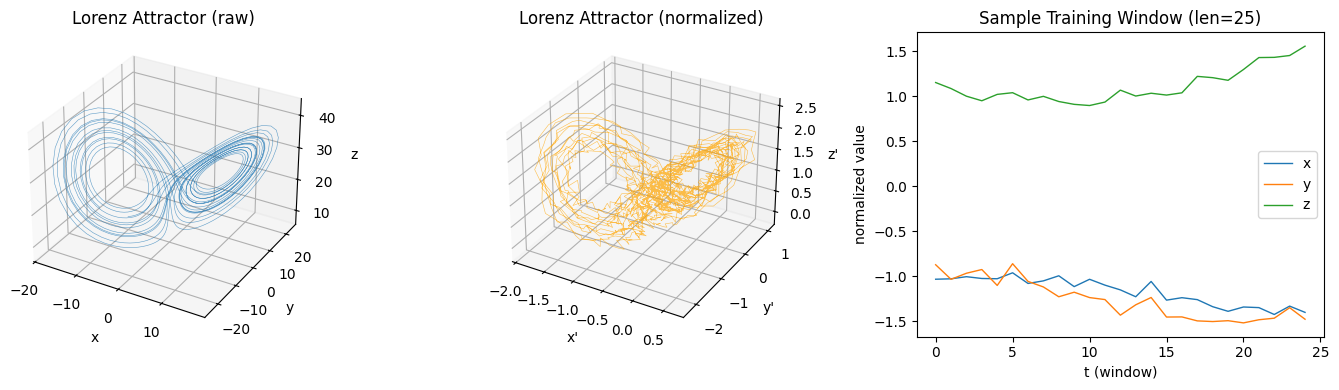

In [14]:
fig = plt.figure(figsize=(14, 4))

# 3D attractor (raw)
ax1 = fig.add_subplot(131, projection='3d')
traj0 = sol["values"][0]
ax1.plot(traj0[:, 0], traj0[:, 1], traj0[:, 2], lw=0.4, alpha=0.7)
ax1.set_title("Lorenz Attractor (raw)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

# Normalized attractor
ax2 = fig.add_subplot(132, projection='3d')
traj_n = values[0]  # normalized, shape (T, 3)
ax2.plot(traj_n[:, 0], traj_n[:, 1], traj_n[:, 2], lw=0.4, alpha=0.7, color='orange')
ax2.set_title("Lorenz Attractor (normalized)")
ax2.set_xlabel("x'"); ax2.set_ylabel("y'"); ax2.set_zlabel("z'")

# Sample training sequences
ax3 = fig.add_subplot(133)
for dim, color, label in zip(range(3), ['C0', 'C1', 'C2'], ['x', 'y', 'z']):
    ax3.plot(sample_batch[0, :, dim].numpy(), color=color, lw=1.0, label=label)
ax3.set_xlabel("t (window)"); ax3.set_ylabel("normalized value")
ax3.set_title(f"Sample Training Window (len={SEQ_LENGTH})")
ax3.legend()

plt.tight_layout()
plt.show()

## 4. Create the Vanilla JacobianODE Model

In [15]:
lit_model = make_model(cfg, dt=dt, eq=eq, mu=mu, sigma=sigma, noise_scale_factor=noise_scale_factor, verbose=True)

print(f"\nModel type:         {type(lit_model).__name__}")
print(f"Jacobian MLP:       {type(lit_model.model).__name__}")
print(f"Direct prediction:  {lit_model.direct}")
print(f"dt:                 {lit_model.dt:.4f}")
print(f"True Lyapunov:      {TRUE_LYAPUNOV}")

jac_params = sum(p.numel() for p in lit_model.model.parameters())
print(f"\nParameters — Jacobian MLP: {jac_params:,}")


Model type:         LitMLP
Jacobian MLP:       MLP
Direct prediction:  True
dt:                 0.0150
True Lyapunov:      [0.91, 0.0, -14.57]

Parameters — Jacobian MLP: 531,977


## 5. Sanity Check: Forward Pass

In [17]:
lit_model.eval()
with torch.no_grad():
    # 1. Predict Jacobians directly from observations
    jacs = lit_model.compute_jacobians(sample_batch)  # (B, T, 3, 3)
    print(f"Jacobians shape:       {jacs.shape}")

    # 2. Full trajectory step
    result = lit_model.trajectory_model_step(sample_batch)
    print(f"\nTrajectory step loss:  {result['loss'].item():.6f}")
    print(f"Metrics:               {result['metric_vals']}")

# Quick gradient check
lit_model.train()
loss = lit_model.training_step(sample_batch, batch_idx=0)
loss.backward()
jac_grad = max(p.grad.abs().max().item() for p in lit_model.model.parameters() if p.grad is not None)
print(f"\nTraining loss:         {loss.item():.6f}")
print(f"Max Jacobian MLP grad: {jac_grad:.2e}")
lit_model.zero_grad()

Jacobians shape:       torch.Size([32, 25, 3, 3])

Trajectory step loss:  0.010325
Metrics:               {'mase': tensor(1.0719), 'r2_score': tensor(0.9891)}

Training loss:         0.010326
Max Jacobian MLP grad: 2.01e-04


## 6. Train the Model

In [18]:
import os, wandb
try:
    wandb.finish(quiet=True)
except Exception:
    pass

In [16]:
# Re-create model to reset any gradient state from the sanity check above.
lit_model = make_model(cfg, dt=dt, eq=eq, mu=mu, sigma=sigma, noise_scale_factor=noise_scale_factor, verbose=False)

RUN_NAME = f"vanilla_jac_lorenz_3d_full"

train_model(
    cfg=cfg,
    lit_model=lit_model,
    train_dataloaders=train_dl,
    val_dataloaders=val_dl,
    name=RUN_NAME,
    project="VanillaLorenz__JacobianODE",
    entity="JacobianODE",
)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.
wandb: Currently logged in as: adamjeisen (JacobianODE) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.htm

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

alpha teacher forcing,██▇▇▇▆▆▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇██
loop_closure train_loss,▁▅▅▄▂█▅▅▇▆▃▅█▅▇▅█▃▄▄▃▅▃▂▃▃▄▃▂▃▄▂▂▃▃▂▂▄▂▁
mean val loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
percent_improvement,█▆▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▂▁▁▂▁▁▁▁▁▁
total train loss,█▆▅▄▅▄▄▃▃▂▁▂▂▂▂▁▂▂▁▃▁▁▁▂▁▁▂▂▁▂▂▁▂▂▁▂▂▂▁▁
train jac loss,▁▁▁▁▂▃▃▄▅▅▅▆▇▇█▇▇▇▇▇█▇▇█▇█▇▇██▇▇█▇▇▇▇▇▇▇
train jac norm,▁▂▃▄▄▅▅▆▆▆▇▇▇██████▇████████████████▇▇██
train jac r2_score,████▇▆▅▅▄▄▃▃▂▂▂▂▂▁▁▂▁▂▁▁▁▁▂▁▁▁▂▂▂▂▂▂▂▂▂▂
train l1 norm,▁▂▂▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████
+10,...


# 7. Load Model and Test

In [ ]:
run_id = 'FILL_IN'

In [ ]:
# ----------------------------------------------------------------
# Load the trained run from Weights & Biases
# ----------------------------------------------------------------
# load_run now handles postprocessing (noise + normalization) internally
# and returns already-processed values.

from JacobianODE.jacobians import load_run, load_checkpoint

# W&B path: entity/project
PROJECT_PATH = f"JacobianODE/VanillaLorenz__JacobianODE"

# ---- Step 1: rebuild architecture + trajectory data (postprocessed) ----
run, cfg, eq, dt, values, _, _, _, _, lit_model = load_run(
    PROJECT_PATH,
    run_id=run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# ---- Step 2: dataloaders from postprocessed data ----
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

# ---- Step 3: load best checkpoint ----
load_checkpoint(run, cfg, lit_model, save_dir=SAVE_DIR, verbose=True)

In [ ]:
sample_batch = test_dl.dataset.sequence[np.random.choice(np.arange(len(test_dl.dataset.sequence)), size=(128,), replace=False)]

In [ ]:
# PROCESS SAMPLE BATCH
with torch.no_grad():
    traj_ret = lit_model.trajectory_model_step(sample_batch, alpha_teacher_forcing=0.0)
    targets_full = sample_batch
    outputs = traj_ret['outputs']

# PROCESS TEST TRAJS
test_trajs = trajs['test_trajs'].sequence
with torch.no_grad():
    jacs_full = lit_model.compute_jacobians(test_trajs)
    # Compute Lyapunov exponents
    from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
    lyaps_full = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_full, dt)

In [ ]:
lyaps_full.mean(axis=0)

In [ ]:
from JacobianODE.jacobians.metrics import r2_score
dim_names = ['x', 'y', 'z']
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)

# Plot predictions vs true (worst case)
pred_portion = outputs[:, traj_init_steps:, :]
true_portion = targets_full[:, traj_init_steps:, :]
plot_ind = ((true_portion - pred_portion)**2).mean(axis=(1, 2)).argmax()
for i in range(3):
    plt.plot(true_portion[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true {dim_names[i]}')
    plt.plot(pred_portion[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted {dim_names[i]}')
plt.legend()
r2_val = r2_score(true_portion.reshape(-1, 3), pred_portion.reshape(-1, 3))
plt.title(f"True vs. Predicted (worst case)\n$R^2 = {r2_val:.4f}$")
plt.show()

In [ ]:
# Plot predictions vs true (best case)
plot_ind = ((true_portion - pred_portion)**2).mean(axis=(1, 2)).argmin()
for i in range(3):
    plt.plot(true_portion[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true {dim_names[i]}')
    plt.plot(pred_portion[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted {dim_names[i]}')
plt.legend()
r2_val = r2_score(true_portion.reshape(-1, 3), pred_portion.reshape(-1, 3))
plt.title(f"True vs. Predicted (best case)\n$R^2 = {r2_val:.4f}$")
plt.show()

In [ ]:
from JacobianODE.jacobians.tuning.criteria import compute_persistence_baseline, compute_one_step_error
lit_model = lit_model.to('cpu')
one_step_error = compute_one_step_error(lit_model, val_dl, n_batches=10, verbose=True)
lit_model.to('cpu')

In [ ]:
from JacobianODE.jacobians.tuning.criteria import compute_one_step_error
lit_model = lit_model.to('cuda')
one_step_error = compute_one_step_error(lit_model, val_dl, n_batches=30, verbose=True)
lit_model = lit_model.to('cpu')

In [ ]:
one_step_error

In [ ]:
compute_persistence_baseline(trajs['train_trajs'].sequence, normalize=True)

## 8. Test 1 — Lyapunov Exponent Comparison

We compute the Jacobians from the learned Jacobian MLP directly on validation
trajectories and then run the standard QR-decomposition Lyapunov algorithm.

Because the true state is **3-dimensional** and fully observed, all three Lyapunov
exponents should match the Lorenz spectrum.

Known Lorenz values: **λ₁ ≈ +0.91, λ₂ ≈ 0.0, λ₃ ≈ −14.57**

In [ ]:
lit_model.eval()

# Collect all validation data
all_obs = []
with torch.no_grad():
    n_iters = 50
    iterator = tqdm(total=n_iters)
    for batch in val_dl:
        all_obs.append(batch)
        iterator.update(1)
        if iterator.n >= n_iters:
            break
    iterator.close()

obs_all = torch.cat(all_obs, dim=0)  # (N_val, T, 3)
print(f"Validation data bank: {obs_all.shape}")

In [ ]:
# Compute Lyapunov exponents from a long concatenated trajectory
N_TRAJ_LYAP = min(30, obs_all.shape[0])
obs_long = obs_all[:N_TRAJ_LYAP].reshape(-1, 3).unsqueeze(0)  # (1, T_long, 3)

with torch.no_grad():
    jacs_long = lit_model.compute_jacobians(obs_long)[0]           # (T_long, 3, 3)
    pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_long, dt)

print("Predicted Lyapunov exponents:")
for i, le in enumerate(pred_lyap):
    print(f"  λ_{i+1} = {le.item():+.4f}")

print("\nTrue Lorenz Lyapunov exponents:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  λ_{i+1} = {le:+.4f}")

true_t = torch.tensor(TRUE_LYAPUNOV)
lyap_mse = ((pred_lyap - true_t) ** 2).mean().item()
print(f"\nLyapunov MSE: {lyap_mse:.4f}")

In [ ]:
N_LATENT = 3  # dimension
fig, ax = plt.subplots(figsize=(6, 4))

x     = np.arange(N_LATENT)
pred_np = pred_lyap.numpy()
true_np = np.array(TRUE_LYAPUNOV)

ax.bar(x - 0.18, pred_np,  width=0.35, label="Predicted", alpha=0.8, color='C0')
ax.bar(x + 0.18, true_np,  width=0.35, label="True (Lorenz)", alpha=0.8, color='C1')

ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xticks(x)
ax.set_xticklabels([f'λ_{i+1}' for i in range(N_LATENT)])
ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum  (MSE={lyap_mse:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Test 2 — Predicted Jacobian vs True Lorenz Jacobian

We verify that the learned Jacobian MLP recovers the true analytical Lorenz Jacobian
directly (no encoder/decoder composition needed).

$$J_{\mathrm{pred}}(x) \approx J_{\mathrm{true}}(x)$$

**Lorenz Jacobian** at $x = (x_1, x_2, x_3)$ (in normalized coords = same as raw since normalization is a global scalar):
$$
J_{\mathrm{true}}(x) = \begin{pmatrix}
-\sigma & \sigma & 0 \\
\rho - x_3 & -1 & -x_1 \\
x_2 & x_1 & -\beta
\end{pmatrix}
$$

In [ ]:
# ---------------------------------------------------------------
# Helper: analytical Lorenz Jacobian
# Note: Since normalization is x_norm = (x - mu)/sigma (global scalar),
# J_lorenz(x_norm) == J_lorenz(x_raw).  Pass denormalized x.
# ---------------------------------------------------------------
def lorenz_jacobian(x_raw, sigma_lz=10.0, rho=28.0, beta=8.0/3.0):
    """Analytical Lorenz Jacobian at x_raw = (x1, x2, x3)."""
    x1, x2, x3 = float(x_raw[0]), float(x_raw[1]), float(x_raw[2])
    return torch.tensor([
        [-sigma_lz, sigma_lz,    0.0 ],
        [rho - x3,  -1.0,       -x1  ],
        [x2,         x1,        -beta],
    ], dtype=torch.float32)

In [ ]:
# ---------------------------------------------------------------
# Compute predicted vs true Jacobians on a test trajectory
# ---------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
lit_model.eval()

# Use one long test sequence
test_seq = trajs['test_trajs'].sequence[:1].to(device)
T_test   = test_seq.shape[1]

# --- sigma and mu may be float or tensor; ensure they're tensors on device
def to_device(x, device):
    if torch.is_tensor(x):
        return x.to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)

sigma_device = to_device(sigma, device)
mu_device    = to_device(mu, device)

# Evaluate every STEP-th timestep
STEP       = 2
T_START    = 5
t_indices  = range(T_START, T_test - 1, STEP)

# Compute predicted Jacobians for the full sequence
with torch.no_grad():
    jacs_pred_all = lit_model.compute_jacobians(test_seq)[0]  # (T, 3, 3)

J_preds = []
J_trues = []

for t_idx in tqdm(t_indices):
    x_t_n = test_seq[0, t_idx].detach()

    # --- Predicted Jacobian (directly from MLP) ---
    J_pred = jacs_pred_all[t_idx].cpu()  # (3, 3)

    # --- True Lorenz Jacobian (in raw/denormalized coords) ---
    x_raw = x_t_n * sigma_device + mu_device               # denormalize
    J_true = lorenz_jacobian(x_raw.cpu())

    J_preds.append(J_pred)
    J_trues.append(J_true)

J_preds = torch.stack(J_preds)   # (N_t, 3, 3)
J_trues = torch.stack(J_trues)   # (N_t, 3, 3)

print(f"Computed {len(t_indices)} Jacobian comparisons")

In [ ]:
# ---------------------------------------------------------------
# Summary metrics
# ---------------------------------------------------------------
frob_errors = torch.norm(J_preds - J_trues, dim=(-2, -1))   # (N_t,)
frob_true   = torch.norm(J_trues,           dim=(-2, -1))
rel_errors  = frob_errors / (frob_true + 1e-8)

# Pearson correlation across all (i,j) entries and timesteps
pred_flat = J_preds.reshape(-1).numpy()
true_flat = J_trues.reshape(-1).numpy()
corr = float(np.corrcoef(pred_flat, true_flat)[0, 1])
r2_jac = r2_score(torch.tensor(true_flat).unsqueeze(0), torch.tensor(pred_flat).unsqueeze(0))

print("Jacobian test results")
print("=" * 38)
print(f"Frobenius error  — mean: {frob_errors.mean():.4f}  |  std: {frob_errors.std():.4f}")
print(f"Relative error   — mean: {rel_errors.mean():.4f}  |  std: {rel_errors.std():.4f}")
print(f"Entry correlation:       {corr:.4f}")
print(f"R^2:                     {r2_jac:.4f}")

# Per-entry breakdown
print("\nPer-entry mean absolute error:")
mae_matrix = (J_preds - J_trues).abs().mean(dim=0).numpy()
print(np.round(mae_matrix, 4))

print("\nMean predicted Jacobian:")
print(np.round(J_preds.mean(dim=0).numpy(), 3))

print("\nMean true Lorenz Jacobian:")
print(np.round(J_trues.mean(dim=0).numpy(), 3))

In [ ]:
# ---------------------------------------------------------------
# Scatter plot: predicted vs true entries  (all timesteps, all 9 entries)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Scatter plot ---
ax = axes[0]
ax.scatter(true_flat, pred_flat, s=2, alpha=0.3, color='C0', rasterized=True)
lim = max(abs(true_flat).max(), abs(pred_flat).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1.0, label='ideal')
ax.set_xlabel("$J_{\\mathrm{true}}$ entries")
ax.set_ylabel("$J_{\\mathrm{pred}}$ entries")
ax.set_title(f"Predicted vs True (r = {corr:.3f})")
ax.legend()

# --- Frobenius error over time ---
ax2 = axes[1]
ax2.plot(list(t_indices), frob_errors.numpy(), lw=1.0, alpha=0.8)
ax2.axhline(frob_errors.mean().item(), color='r', ls='--', lw=1.0,
            label=f'mean = {frob_errors.mean():.3f}')
ax2.set_xlabel("Timestep in test window")
ax2.set_ylabel("Frobenius error")
ax2.set_title("$\\|J_{\\mathrm{pred}} - J_{\\mathrm{true}}\\|_F$")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Per-entry (i,j) scatter:  one subplot per Jacobian entry
# ---------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(11, 10))
row_labels = ['x', 'y', 'z']
col_labels = ['x', 'y', 'z']

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        p  = J_preds[:, i, j].numpy()
        t  = J_trues[:, i, j].numpy()
        r  = float(np.corrcoef(p, t)[0, 1]) if np.std(p) > 1e-8 and np.std(t) > 1e-8 else float('nan')

        ax.scatter(t, p, s=4, alpha=0.5, color='C0', rasterized=True)
        mn, mx = min(t.min(), p.min()), max(t.max(), p.max())
        pad = (mx - mn) * 0.05 if mx > mn else 0.1
        ax.plot([mn-pad, mx+pad], [mn-pad, mx+pad], 'k--', lw=0.8)
        ax.set_title(f"({row_labels[i]},{col_labels[j]})  r={r:.2f}")
        ax.set_xlabel("true")
        ax.set_ylabel("pred")

fig.suptitle("Predicted $J_{\\mathrm{pred}}$ vs $J_{\\mathrm{true}}$ — per entry", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Heatmap comparison at a single representative timestep
# ---------------------------------------------------------------
mid = len(t_indices) // 2

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

vabs = max(J_trues[mid].abs().max().item(),
           J_preds[mid].abs().max().item())

im0 = axes[0].imshow(J_trues[mid].numpy(),  vmin=-vabs, vmax=vabs, cmap='RdBu_r')
im1 = axes[1].imshow(J_preds[mid].numpy(),  vmin=-vabs, vmax=vabs, cmap='RdBu_r')
diff = (J_preds[mid] - J_trues[mid]).numpy()
im2 = axes[2].imshow(diff, cmap='RdBu_r',
                     vmin=-abs(diff).max(), vmax=abs(diff).max())

for ax, im, title in zip(axes, [im0, im1, im2],
                          ['$J_{\\mathrm{true}}$',
                           '$J_{\\mathrm{pred}}$',
                           'Difference']):
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['x', 'y', 'z'])
    ax.set_yticklabels(['x', 'y', 'z'])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

t_shown = list(t_indices)[mid]
fig.suptitle(f"Jacobian heatmaps at t={t_shown}  "
             f"(Frob. error = {frob_errors[mid]:.4f})", y=1.03)
plt.tight_layout()
plt.show()

## 10. Summary

| Test | Metric | Target | Result |
|------|--------|--------|--------|
| **Lyapunov exponents** | MSE vs true | < 1.0 | `lyap_mse` above |
| **Predicted Jacobian** | Entry correlation | > 0.9 | `corr` above |
| **Predicted Jacobian** | Mean relative Frob. error | < 0.3 | `rel_errors.mean()` above |

The vanilla JacobianODE directly learns the Jacobian field in observation space.
Since the system is fully observed (3D → 3D), no encoder/decoder is needed.

### Hyperparameter Reference

| Category | Parameter | Value | Notes |
|----------|-----------|-------|-------|
| **System** | Observed dims | 3/3 | Fully observed |
| **JacMLP** | `hidden_dim` | [512,512,512] | 3D system |
| **JacMLP** | `activation` | silu | |
| **JacODE** | `traj_init_steps` | 15 | Init steps |
| **Batch** | `SEQ_LENGTH` | 50 | Window length |
| **Batch** | `BATCH_SIZE` | 32 | Batch size |